<a href="https://colab.research.google.com/github/UROOJKHANdev/ARTIFICIAL_INTELLIGENCE-AND-DATA-SCIENCE-MODELS-/blob/main/RANDOM_FOREST_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [82]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [83]:
df= pd.read_csv('/content/Heart_Disease_Prediction.csv')
df

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,70,1,4,130,322,0,2,109,0,2.4,2,3,3,Presence
1,67,0,3,115,564,0,2,160,0,1.6,2,0,7,Absence
2,57,1,2,124,261,0,0,141,0,0.3,1,0,7,Presence
3,64,1,4,128,263,0,0,105,1,0.2,2,1,7,Absence
4,74,0,2,120,269,0,2,121,1,0.2,1,1,3,Absence
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
265,52,1,3,172,199,1,0,162,0,0.5,1,0,7,Absence
266,44,1,2,120,263,0,0,173,0,0.0,1,0,7,Absence
267,56,0,2,140,294,0,2,153,0,1.3,2,0,3,Absence
268,57,1,4,140,192,0,0,148,0,0.4,2,0,6,Absence


In [84]:
df.head()

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,70,1,4,130,322,0,2,109,0,2.4,2,3,3,Presence
1,67,0,3,115,564,0,2,160,0,1.6,2,0,7,Absence
2,57,1,2,124,261,0,0,141,0,0.3,1,0,7,Presence
3,64,1,4,128,263,0,0,105,1,0.2,2,1,7,Absence
4,74,0,2,120,269,0,2,121,1,0.2,1,1,3,Absence


In [85]:
df.columns


Index(['Age', 'Sex', 'Chest pain type', 'BP', 'Cholesterol', 'FBS over 120',
       'EKG results', 'Max HR', 'Exercise angina', 'ST depression',
       'Slope of ST', 'Number of vessels fluro', 'Thallium', 'Heart Disease'],
      dtype='object')

In [86]:
df.shape


(270, 14)

In [87]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 270 entries, 0 to 269
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      270 non-null    int64  
 1   Sex                      270 non-null    int64  
 2   Chest pain type          270 non-null    int64  
 3   BP                       270 non-null    int64  
 4   Cholesterol              270 non-null    int64  
 5   FBS over 120             270 non-null    int64  
 6   EKG results              270 non-null    int64  
 7   Max HR                   270 non-null    int64  
 8   Exercise angina          270 non-null    int64  
 9   ST depression            270 non-null    float64
 10  Slope of ST              270 non-null    int64  
 11  Number of vessels fluro  270 non-null    int64  
 12  Thallium                 270 non-null    int64  
 13  Heart Disease            270 non-null    object 
dtypes: float64(1), int64(12), 

In [88]:
df.isnull().sum()


,0
Age,0
Sex,0
Chest pain type,0
BP,0
Cholesterol,0
FBS over 120,0
EKG results,0
Max HR,0
Exercise angina,0
ST depression,0


In [89]:
print("\nDuplicate Rows:", df.duplicated().sum())


Duplicate Rows: 0


In [90]:
df.drop_duplicates(inplace=True)


In [91]:
print(df.dtypes)

Age                          int64
Sex                          int64
Chest pain type              int64
BP                           int64
Cholesterol                  int64
FBS over 120                 int64
EKG results                  int64
Max HR                       int64
Exercise angina              int64
ST depression              float64
Slope of ST                  int64
Number of vessels fluro      int64
Thallium                     int64
Heart Disease               object
dtype: object


In [92]:
print(df.columns.tolist())

['Age', 'Sex', 'Chest pain type', 'BP', 'Cholesterol', 'FBS over 120', 'EKG results', 'Max HR', 'Exercise angina', 'ST depression', 'Slope of ST', 'Number of vessels fluro', 'Thallium', 'Heart Disease']


In [93]:
target = "Heart Disease"

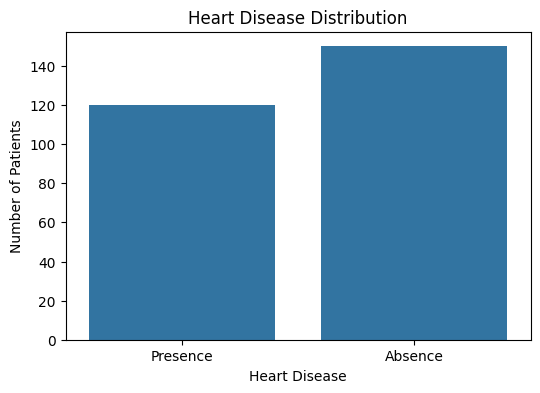

In [94]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))

sns.countplot(
    x=target,
    data=df
)

plt.title("Heart Disease Distribution")
plt.xlabel("Heart Disease")
plt.ylabel("Number of Patients")

plt.show()

In [95]:
print(df[target].value_counts())

Heart Disease
Absence     150
Presence    120
Name: count, dtype: int64


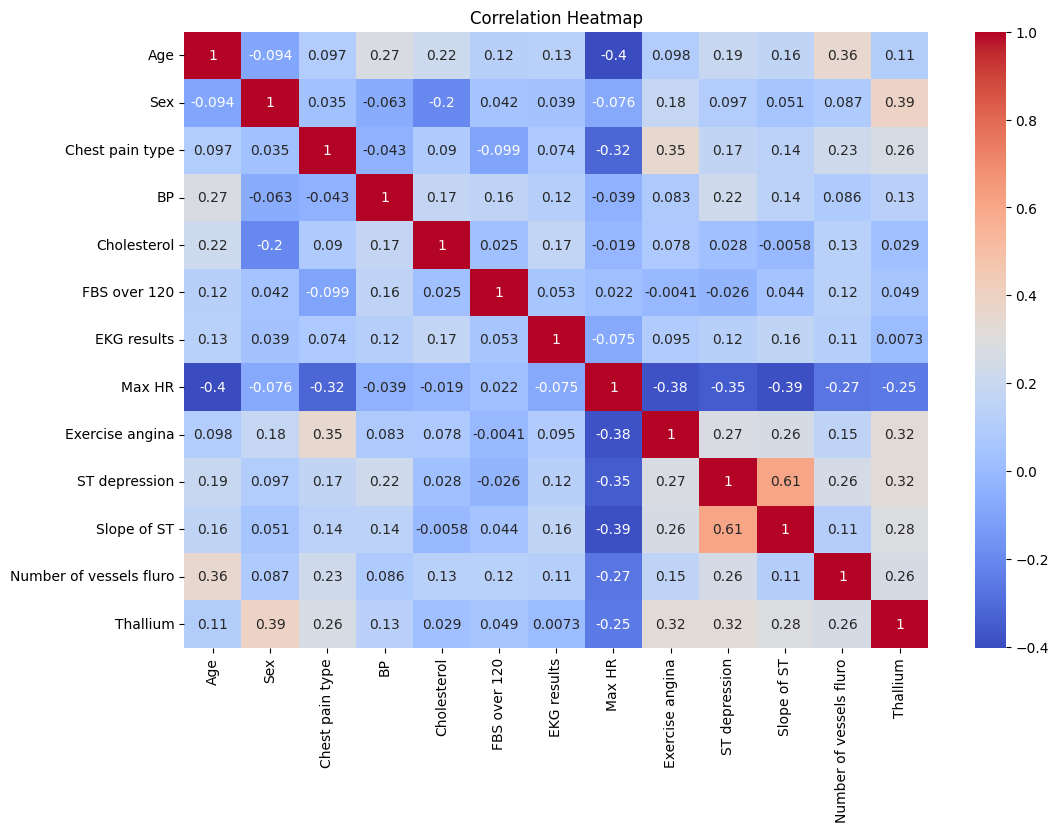

In [96]:
plt.figure(figsize=(12,8))

correlation = df.select_dtypes(
    include=['number']
).corr()

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

In [97]:
X = df.drop(columns=[target])
y = df[target]

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (270, 13)
Target Shape: (270,)


In [98]:
categorical_features = X.select_dtypes(
    include=['object']
).columns

print("Categorical Features:")
print(categorical_features.tolist())

Categorical Features:
[]


In [99]:
numerical_features = X.select_dtypes(
    include=['int64', 'float64']
).columns

print("\nNumerical Features:")
print(numerical_features.tolist())


Numerical Features:
['Age', 'Sex', 'Chest pain type', 'BP', 'Cholesterol', 'FBS over 120', 'EKG results', 'Max HR', 'Exercise angina', 'ST depression', 'Slope of ST', 'Number of vessels fluro', 'Thallium']


In [100]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (216, 13)
X_test: (54, 13)
y_train: (216,)
y_test: (54,)


In [101]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
)

print(rf_model)

RandomForestClassifier(class_weight='balanced', n_jobs=-1, random_state=42)


In [102]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

In [103]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            'categorical',
            OneHotEncoder(handle_unknown='ignore'),
            categorical_features
        )
    ],
    remainder='passthrough'
)

In [104]:
rf_pipeline = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', rf_model)
    ]
)

In [105]:
rf_pipeline.fit(
    X_train,
    y_train
)

print("Random Forest trained successfully!")

Random Forest trained successfully!


In [106]:
print(y.unique())

['Presence' 'Absence']


In [107]:
y_pred = rf_pipeline.predict(X_test)

print("Predictions:")
print(y_pred[:20])

Predictions:
['Absence' 'Absence' 'Absence' 'Presence' 'Absence' 'Absence' 'Absence'
 'Presence' 'Presence' 'Presence' 'Absence' 'Absence' 'Absence' 'Presence'
 'Presence' 'Presence' 'Absence' 'Presence' 'Absence' 'Presence']


In [108]:
y_prob = rf_pipeline.predict_proba(X_test)[:, 1]

print("Prediction Probabilities:")
print(y_prob[:20])

Prediction Probabilities:
[0.13 0.16 0.18 0.83 0.27 0.13 0.08 0.93 0.64 0.79 0.16 0.36 0.14 0.89
 0.56 0.95 0.01 0.81 0.15 0.84]


In [109]:
comparison = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred
})

print(comparison.head(20))

      Actual Predicted
0    Absence   Absence
1    Absence   Absence
2    Absence   Absence
3   Presence  Presence
4    Absence   Absence
5    Absence   Absence
6    Absence   Absence
7   Presence  Presence
8   Presence  Presence
9   Presence  Presence
10   Absence   Absence
11  Presence   Absence
12   Absence   Absence
13   Absence  Presence
14  Presence  Presence
15  Presence  Presence
16   Absence   Absence
17  Presence  Presence
18   Absence   Absence
19  Presence  Presence


In [110]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(
    y_test,
    y_pred
)

print("Accuracy:", accuracy)

Accuracy: 0.8148148148148148


In [111]:
from sklearn.metrics import classification_report

print("Classification Report:")

print(
    classification_report(
        y_test,
        y_pred,
        zero_division=0
    )
)

Classification Report:
              precision    recall  f1-score   support

     Absence       0.86      0.80      0.83        30
    Presence       0.77      0.83      0.80        24

    accuracy                           0.81        54
   macro avg       0.81      0.82      0.81        54
weighted avg       0.82      0.81      0.82        54



In [112]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    y_pred
)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[24  6]
 [ 4 20]]


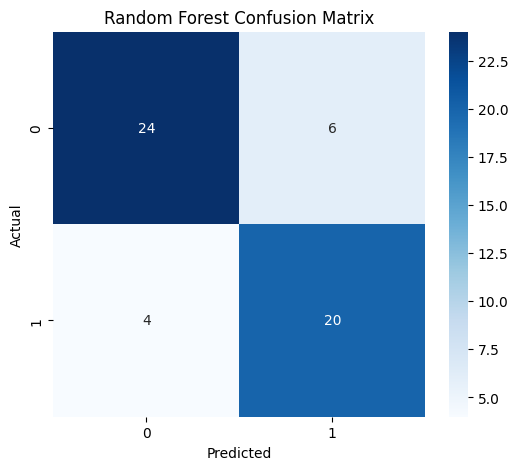

In [113]:
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Random Forest Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [114]:
from sklearn.metrics import roc_auc_score

roc_auc = roc_auc_score(
    y_test,
    y_prob
)

print("ROC-AUC Score:", roc_auc)

ROC-AUC Score: 0.8680555555555556


In [115]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [None, 10, 20],
    'model__min_samples_split': [2, 5],
    'model__min_samples_leaf': [1, 2]
}

grid_search = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(
    X_train,
    y_train
)

print("\nBest Parameters:")
print(grid_search.best_params_)

print("\nBest CV F1 Weighted Score:")
print(grid_search.best_score_)

Fitting 5 folds for each of 24 candidates, totalling 120 fits

Best Parameters:
{'model__max_depth': None, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 200}

Best CV F1 Weighted Score:
0.8325900213511721


In [116]:
print("Best Cross-Validation F1 Score:")

print(
    grid_search.best_score_
)

Best Cross-Validation F1 Score:
0.8325900213511721


In [117]:
from sklearn.model_selection import cross_val_score

best_model = grid_search.best_estimator_

cv_scores = cross_val_score(
    best_model,
    X_train,
    y_train,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1
)

print("Cross Validation Scores:")
print(cv_scores)

print("\nMean CV F1 Score:")
print(cv_scores.mean())

Cross Validation Scores:
[0.81507382 0.72093023 0.83756455 0.93000167 0.85937984]

Mean CV F1 Score:
0.8325900213511721


In [118]:
best_model = grid_search.best_estimator_

print(best_model)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('categorical',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index([], dtype='object'))])),
                ('model',
                 RandomForestClassifier(class_weight='balanced',
                                        n_estimators=200, n_jobs=-1,
                                        random_state=42))])


In [119]:
final_pred = best_model.predict(X_test)

final_prob = best_model.predict_proba(
    X_test
)[:, 1]

In [120]:
print("========== FINAL RESULTS ==========")

print(
    "Accuracy:",
    accuracy_score(y_test, final_pred)
)

print("\nClassification Report:")

print(
    classification_report(
        y_test,
        final_pred,
        zero_division=0
    )
)

print(
    "ROC-AUC:",
    roc_auc_score(
        y_test,
        final_prob
    )
)

========== FINAL RESULTS ==========
Accuracy: 0.8148148148148148

Classification Report:
              precision    recall  f1-score   support

     Absence       0.86      0.80      0.83        30
    Presence       0.77      0.83      0.80        24

    accuracy                           0.81        54
   macro avg       0.81      0.82      0.81        54
weighted avg       0.82      0.81      0.82        54

ROC-AUC: 0.8729166666666668


In [121]:
import joblib

joblib.dump(
    best_model,
    "/content/random_forest_heart_disease.pkl"
)

print("Model saved successfully!")

Model saved successfully!


In [122]:
loaded_model = joblib.load(
    "/content/random_forest_heart_disease.pkl"
)

print("Model loaded successfully!")

Model loaded successfully!


In [123]:
new_patient = X_test.iloc[[0]]

prediction = loaded_model.predict(
    new_patient
)

probability = loaded_model.predict_proba(
    new_patient
)[:, 1]

print("Prediction:", prediction[0])
print("Probability:", probability[0])

Prediction: Absence
Probability: 0.125


In [124]:
if prediction[0] == 1:
    print("Result: Heart Disease")
else:
    print("Result: No Heart Disease")

Result: No Heart Disease
